## K-nearest Neighbour

In [2]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [8]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [9]:
diff.to_excel("diabetes_data.xlsx")

In [10]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


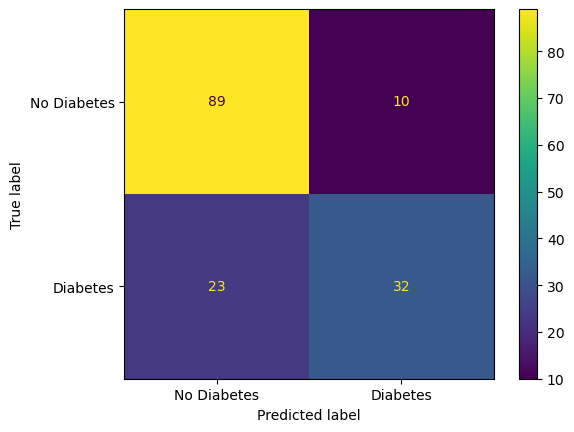

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Diabetes","Diabetes"])
cm_display.plot()
plt.show()

In [12]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print("TN:",TN,"FP:",FP,"FN:",FN,"TP:",TP)

TN: 89 FP: 10 FN: 23 TP: 32


In [18]:
accuracy=(TN+TP)/(TN+FP+FN+TP)
print("Accuracy Score:",accuracy)

Accuracy Score: 0.7857142857142857


In [19]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

Accuracy Score: 0.7857142857142857


In [20]:
Error_Rate=(FN+FP)/(TN+FP+FN+TP)
print("Error Rate:",Error_Rate)# or 1-accuracy

Error Rate: 0.21428571428571427


In [21]:
sensitivity=TP/(TP+FN)
specificity=TN/(TN+FP)
print("Sensitivity:",sensitivity)
print("Specificity:",specificity)

Sensitivity: 0.5818181818181818
Specificity: 0.898989898989899


In [23]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,prediction))# default value of pos_label=1
print("Specificity:",recall_score(y_test,prediction,pos_label=0))

Sensitivity: 0.5818181818181818
Specificity: 0.898989898989899


In [24]:
Precision_Score=TP/(TP+FP)
print("Precision Score(for Positive):",Precision_Score)

Precision Score: 0.7619047619047619


In [27]:
from sklearn.metrics import precision_score
print("Precision Score(for Positive):",precision_score(y_test,prediction))
print("Precision Score(for Negative):",precision_score(y_test,prediction,pos_label=0))

Precision Score(for Positive): 0.7619047619047619
Precision Score(for Negative): 0.7946428571428571


In [28]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
accuracy=[]
for i in range(1,31):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    accuracy.append(accuracy_score(y_test,prediction))
accuracy

[0.7207792207792207,
 0.7272727272727273,
 0.7402597402597403,
 0.7207792207792207,
 0.7337662337662337,
 0.7727272727272727,
 0.7597402597402597,
 0.7662337662337663,
 0.7662337662337663,
 0.7597402597402597,
 0.7467532467532467,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7857142857142857,
 0.7857142857142857,
 0.7857142857142857,
 0.7727272727272727,
 0.7727272727272727,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7662337662337663,
 0.7792207792207793,
 0.7532467532467533,
 0.7727272727272727,
 0.7532467532467533,
 0.7662337662337663,
 0.7662337662337663,
 0.7792207792207793]

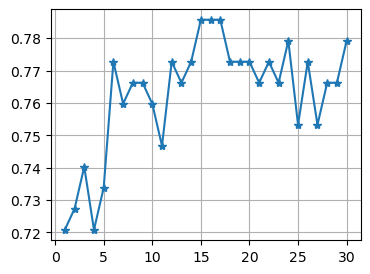

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(range(1,31),accuracy,marker="*")
plt.grid(True)
plt.show()

In [30]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [31]:
x=df.iloc[:,0:2]
y=df["Size"]
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [39]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [40]:
diff=pd.DataFrame({"Actual":y,"Predicted":prediction})
diff

,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [41]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 0.8888888888888888


In [43]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


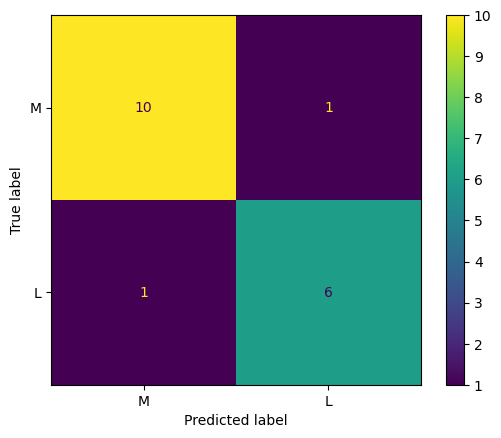

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["M","L"])
cm_display.plot()
plt.show()

In [47]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y,prediction,pos_label="M"))
print("Specificity:",recall_score(y,prediction,pos_label="L"))

Sensitivity: 0.8571428571428571
Specificity: 0.9090909090909091


In [48]:
df=pd.read_csv("AptitudeCommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [52]:
x=df.iloc[:,1:3]
y=df["Class"]
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [62]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=3)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [63]:
diff=pd.DataFrame({"Actual":y,"Predicted":prediction})
diff

,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [64]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


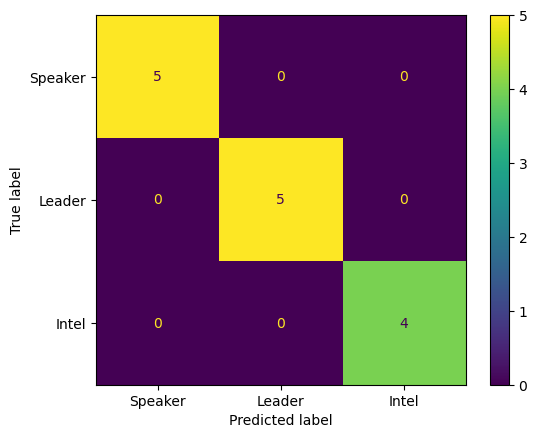

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Speaker","Leader","Intel"])
cm_display.plot()
plt.show()

In [67]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 1.0
